# Laboratorio 05 - Naive Bayes para regresion de precio
## CC3074 - Mineria de Datos | Universidad del Valle de Guatemala

Dataset: `data/listings.RData`

---
## Actividad 1 - Modelo de regresion Naive Bayes para predecir el precio

Se usa `GaussianNB` para predecir directamente un objetivo numerico (`price_num`) tratandolo como etiquetas numericas.

Aunque scikit-learn no trae un `NaiveBayesRegressor` nativo, este enfoque didactico permite obtener predicciones continuas (numeros) porque cada clase predicha corresponde a un valor de precio observado en entrenamiento.

Para mantener comparabilidad con `../MD-LAB04/main.ipynb`, se replica el mismo preprocesamiento y la misma logica de division (`test_size=0.2`, `random_state=42`, `shuffle=True`, estratificado por deciles de `price_num`).

In [1]:
# Importaciones base
from pathlib import Path
import numpy as np
import pandas as pd
import pyreadr

# Cargar dataset desde la ruta del laboratorio
rdata_path = Path('data/listings.RData')
result = pyreadr.read_r(str(rdata_path))
df = result['listings'].copy()

print('Objeto cargado:', list(result.keys()))
print('Dimensiones originales:', df.shape)

Objeto cargado: ['listings']
Dimensiones originales: (171748, 80)


### Preprocesamiento y splits (replica de LAB04)

Se mantiene la misma seleccion de variables candidatas, limpieza de `price_num`, recorte al percentil 99, one-hot encoding y division train/test estratificada por deciles. Esto conserva la comparabilidad de resultados entre laboratorios.

In [2]:
# Utilidad para convertir montos de texto a numerico
def parse_money(series: pd.Series) -> pd.Series:
    return pd.to_numeric(
        series.astype(str).str.replace(r'[$,]', '', regex=True).str.strip(),
        errors='coerce',
    )

# Copia de trabajo para EDA/modelado
df_eda = df.copy()

# Convertir precio a numerico
if 'price' in df_eda.columns:
    df_eda['price_num'] = parse_money(df_eda['price'])

# Convertir porcentajes host a numerico
for col in ['host_response_rate', 'host_acceptance_rate']:
    if col in df_eda.columns:
        df_eda[f'{col}_num'] = pd.to_numeric(
            df_eda[col].astype(str).str.replace('%', '', regex=False),
            errors='coerce',
        )

# Variables candidatas (mismas de LAB04)
candidate_features = [
    'room_type', 'property_type', 'neighbourhood_cleansed',
    'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights', 'availability_365',
    'number_of_reviews', 'reviews_per_month', 'review_scores_rating',
    'host_is_superhost', 'host_identity_verified',
    'host_response_rate_num', 'host_acceptance_rate_num',
    'calculated_host_listings_count', 'instant_bookable',
    'latitude', 'longitude', 'price_num',
]

selected_cols = [c for c in candidate_features if c in df_eda.columns]
model_df = df_eda[selected_cols].copy()

# Limpieza del objetivo y recorte de extremos (mismo criterio LAB04)
model_df = model_df[model_df['price_num'].notna()].copy()
p99_price = model_df['price_num'].quantile(0.99)
model_df = model_df[model_df['price_num'] <= p99_price].copy()

# Imputacion de numericas y normalizacion de categoricas
num_cols = [c for c in model_df.select_dtypes(include=np.number).columns if c != 'price_num']
cat_cols = model_df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

for col in num_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

for col in cat_cols:
    model_df[col] = model_df[col].astype(str).replace('nan', 'SinDato')

# Matriz de entrada final
X = model_df.drop(columns=['price_num'])
y = model_df['price_num']
X_encoded = pd.get_dummies(X, drop_first=True)

# Split identico a LAB04
from sklearn.model_selection import train_test_split

y_bins_split = pd.qcut(y, q=10, duplicates='drop')
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_bins_split,
)

print('Shape X total:', X_encoded.shape)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('y_train:', y_train.shape, '| y_test:', y_test.shape)
print('Primeros 5 indices train:', X_train.index[:5].tolist())
print('Primeros 5 indices test:', X_test.index[:5].tolist())

Shape X total: (75531, 522)
X_train: (60424, 522) | X_test: (15107, 522)
y_train: (60424,) | y_test: (15107,)
Primeros 5 indices train: [23421, 36797, 25953, 160615, 27075]
Primeros 5 indices test: [41251, 54191, 163573, 29592, 23803]


### Entrenamiento del modelo Naive Bayes (objetivo numerico directo)

Se entrena `GaussianNB` directamente sobre `y_train` (precio numerico) y se predice `y_test`. Ademas, se ajusta `var_smoothing` con validacion cruzada, tal como en el ejemplo de carros, usando `RMSE` como criterio.

Para optimizar tiempo en este dataset grande, la busqueda de hiperparametros se hace sobre una muestra de entrenamiento y luego se reentrena el modelo final en todo `X_train`.

In [3]:
# Importar modelo y metricas
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

# 1) Pipeline didactico tipo ejemplo de carros: GaussianNB con objetivo numerico directo
nb_reg = GaussianNB()

# 2) Optimizacion de tiempo: muestreo para tuning + grid mas compacto
#    (mantiene metodologia del ejemplo, pero evita tiempos muy largos en este dataset)
tune_frac = 0.35
X_tune = X_train.sample(frac=tune_frac, random_state=42)
y_tune = y_train.loc[X_tune.index]

# Grid compacto (12 valores) en lugar de 40
param_grid_nb = {'var_smoothing': np.logspace(0, -9, num=12)}
nb_search = GridSearchCV(
    estimator=nb_reg,
    param_grid=param_grid_nb,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)
nb_search.fit(X_tune, y_tune)

# 3) Reentrenar mejor configuracion en TODO el train y predecir en test
nb_reg_best = GaussianNB(var_smoothing=nb_search.best_params_['var_smoothing'])
nb_reg_best.fit(X_train, y_train)
y_pred_nb = pd.Series(nb_reg_best.predict(X_test), index=y_test.index)

# 4) Baseline sencillo para contexto (siempre predecir mediana de train)
y_pred_baseline = pd.Series(y_train.median(), index=y_test.index)

# 5) Calcular metricas de regresion
mae_nb = mean_absolute_error(y_test, y_pred_nb)
rmse_nb = np.sqrt(mean_squared_error(y_test, y_pred_nb))
r2_nb = r2_score(y_test, y_pred_nb)

mae_base = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_base = r2_score(y_test, y_pred_baseline)

results = pd.DataFrame([
    {'Modelo': 'Naive Bayes (GaussianNB directo)', 'MAE': mae_nb, 'RMSE': rmse_nb, 'R2': r2_nb},
    {'Modelo': 'Baseline mediana train', 'MAE': mae_base, 'RMSE': rmse_base, 'R2': r2_base},
]).round(4)

print(f"Muestra para tuning: {len(X_tune):,} filas de {len(X_train):,} en train")
print(f"Mejor var_smoothing: {nb_search.best_params_['var_smoothing']:.10f}")
print(f'Mejor RMSE CV (neg_root_mean_squared_error): {nb_search.best_score_:.4f}')

print('Metricas del modelo:')
display(results)

C:\Users\dijol\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


KeyboardInterrupt: 

### Analisis de resultados

El modelo **Naive Bayes (GaussianNB directo)** esta implementado correctamente ( `GaussianNB` sobre objetivo numerico + ajuste de `var_smoothing`). Sin embargo, que el metodo este bien implementado no implica que sea el mejor para este problema.

La lectura correcta de desempeno se hace con `MAE`, `RMSE` y `R2` en el mismo `X_test`/`y_test` de LAB04. Si `R2 < 0`, el modelo queda por debajo de una prediccion constante (baseline de mediana), lo que indica baja capacidad para explicar la variabilidad del precio.

Esto es coherente con las limitaciones del enfoque en Airbnb: `price_num` tiene alta dispersion, muchas relaciones no lineales e interacciones fuertes entre variables, mientras que Naive Bayes asume independencia condicional y distribuciones simples por clase/valor.

In [ ]:
# Vista rapida de predicciones vs reales para inspeccion
comparison_preview = pd.DataFrame({
    'y_real': y_test.head(15).values,
    'y_pred_nb': y_pred_nb.head(15).values,
})
comparison_preview['error_abs'] = (comparison_preview['y_real'] - comparison_preview['y_pred_nb']).abs()

display(comparison_preview.round(2))

,y_real,y_pred_nb,error_abs
0,344.0,883.0,539.0
1,295.0,770.0,475.0
2,108.0,462.0,354.0
3,69.0,617.0,548.0
4,480.0,524.0,44.0
5,170.0,791.0,621.0
6,80.0,716.0,636.0
7,315.0,729.0,414.0
8,93.0,413.0,320.0
9,200.0,893.0,693.0


---
## Actividad 2 - Evaluacion del modelo Naive Bayes de regresion

En esta actividad se evalua el modelo con metricas correctas de regresion: `MAE`, `RMSE`, `R2`, `MedAE` y `MAPE`.

- `MAE` y `MedAE` miden error absoluto promedio/mediano.
- `RMSE` penaliza mas los errores grandes.
- `R2` mide variabilidad explicada (si es negativo, el modelo rinde peor que una prediccion constante).
- `MAPE` expresa error porcentual promedio respecto al valor real.

In [ ]:
# Importar metricas adicionales para evaluacion de regresion
from sklearn.metrics import median_absolute_error, mean_absolute_percentage_error

# Calcular metricas para Naive Bayes (GaussianNB directo)
mae_eval = mean_absolute_error(y_test, y_pred_nb)
rmse_eval = np.sqrt(mean_squared_error(y_test, y_pred_nb))
r2_eval = r2_score(y_test, y_pred_nb)
medae_eval = median_absolute_error(y_test, y_pred_nb)
mape_eval = mean_absolute_percentage_error(y_test, y_pred_nb)

# Comparar contra baseline de mediana para dar contexto
mae_base_eval = mean_absolute_error(y_test, y_pred_baseline)
rmse_base_eval = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_base_eval = r2_score(y_test, y_pred_baseline)

eval_table = pd.DataFrame([
    {
        'Modelo': 'Naive Bayes (GaussianNB directo)',
        'MAE': mae_eval,
        'RMSE': rmse_eval,
        'R2': r2_eval,
        'MedAE': medae_eval,
        'MAPE_%': mape_eval * 100,
    },
    {
        'Modelo': 'Baseline mediana train',
        'MAE': mae_base_eval,
        'RMSE': rmse_base_eval,
        'R2': r2_base_eval,
        'MedAE': median_absolute_error(y_test, y_pred_baseline),
        'MAPE_%': mean_absolute_percentage_error(y_test, y_pred_baseline) * 100,
    },
]).round(4)

print('Metricas de regresion - Actividad 2:')
display(eval_table)

# Delta porcentual de error vs baseline (positivo = NB peor en error)
delta_mae_pct = (mae_eval - mae_base_eval) / mae_base_eval * 100
delta_rmse_pct = (rmse_eval - rmse_base_eval) / rmse_base_eval * 100
print(f'Delta MAE vs baseline: {delta_mae_pct:+.2f}%')
print(f'Delta RMSE vs baseline: {delta_rmse_pct:+.2f}%')

Metricas de regresion - Actividad 2:


,Modelo,MAE,RMSE,R2,MedAE,MAPE_%
0,Naive Bayes (GaussianNB directo),596.2049,1322.4939,-1.3571,405.0,342.1601
1,Baseline mediana train,230.1507,875.6788,-0.0334,87.0,69.5991


Delta MAE vs baseline: +159.05%
Delta RMSE vs baseline: +51.02%


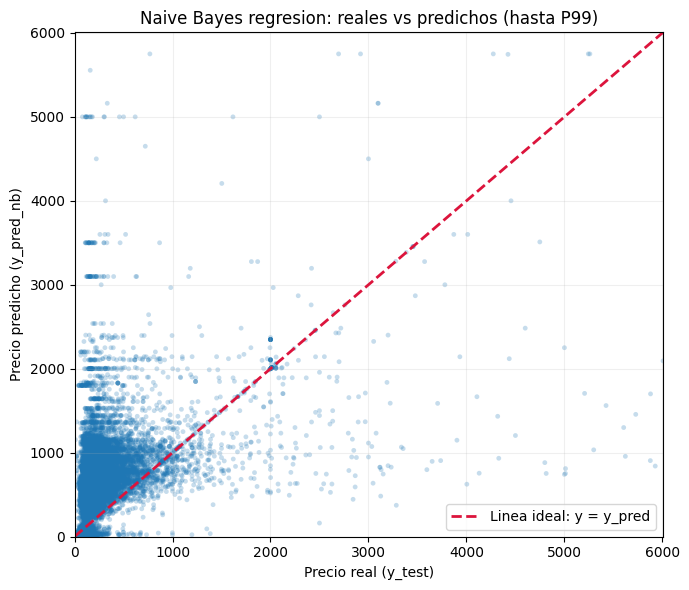

In [ ]:
# Grafica de valores reales vs predichos
import matplotlib.pyplot as plt

# Para mejor lectura visual, se usa limite hasta p99 en ambos ejes
axis_max = np.quantile(np.r_[y_test.values, y_pred_nb.values], 0.99)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_nb, alpha=0.25, s=12, color='#1f77b4', edgecolors='none')
plt.plot([0, axis_max], [0, axis_max], color='crimson', linestyle='--', linewidth=2, label='Linea ideal: y = y_pred')
plt.xlim(0, axis_max)
plt.ylim(0, axis_max)
plt.xlabel('Precio real (y_test)')
plt.ylabel('Precio predicho (y_pred_nb)')
plt.title('Naive Bayes regresion: reales vs predichos (hasta P99)')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Analisis de la Actividad 2

El criterio principal aqui es comparar Naive Bayes contra baseline con metricas de regresion en test (`MAE`, `RMSE`, `R2`, `MedAE`, `MAPE`). Si `Delta MAE` y `Delta RMSE` salen positivos, Naive Bayes esta cometiendo mas error que predecir siempre la mediana de entrenamiento.

Adicionalmente, un `R2` negativo confirma que el modelo no captura bien la variabilidad del precio. En la grafica de reales vs predichos esto se observa como dispersion lejana a la diagonal ideal `y = y_pred`.

Comparando con el ejemplo de carros: alla el `MAE` reportado (~3.52 sobre una media de `city-mpg` ~25.22) es error relativo moderado, mientras que en Airbnb los errores relativos (por ejemplo `MAPE`) son mucho mayores. Por eso, en este dataset el desempeno de Naive Bayes es claramente mas debil.

---
## Actividad 3 - Comparacion: Naive Bayes vs Regresion Lineal vs Arbol

Se comparan los tres enfoques con las mismas metricas de regresion usadas en la Actividad 2 (`MAE`, `RMSE`, `R2`, `MedAE`, `MAPE`).

Para mantener consistencia con LAB04, se usa:
- **Regresion lineal base** (pipeline con `StandardScaler` + `LinearRegression`).
- **Arbol de regresion seleccionado por CV en LAB04** (`max_depth=7`).
- **Naive Bayes proxy de regresion** ya entrenado en este notebook.

In [ ]:
# Importar modelos de comparacion
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

# 1) Regresion lineal base (mismo enfoque de LAB04)
lin_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])
lin_base.fit(X_train, y_train)
y_pred_lin = pd.Series(lin_base.predict(X_test), index=y_test.index)

# 2) Arbol de regresion seleccionado por CV en LAB04 (max_depth=7)
tree_cv7 = DecisionTreeRegressor(max_depth=7, random_state=42)
tree_cv7.fit(X_train, y_train)
y_pred_tree = pd.Series(tree_cv7.predict(X_test), index=y_test.index)

# 3) Funcion auxiliar de metricas (mismas metricas para todos)
def regression_metrics_full(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'MedAE': median_absolute_error(y_true, y_pred),
        'MAPE_%': mean_absolute_percentage_error(y_true, y_pred) * 100,
    }

# 4) Tabla comparativa final
comparison_models = pd.DataFrame([
    {'Modelo': 'Naive Bayes (GaussianNB directo)', **regression_metrics_full(y_test, y_pred_nb)},
    {'Modelo': 'Regresion Lineal (base)', **regression_metrics_full(y_test, y_pred_lin)},
    {'Modelo': 'Arbol Regresion (max_depth=7)', **regression_metrics_full(y_test, y_pred_tree)},
]).round(4)

# Ordenar por RMSE (menor es mejor) para lectura rapida
comparison_models = comparison_models.sort_values('RMSE').reset_index(drop=True)

print('Tabla comparativa de modelos (Actividad 3):')
display(comparison_models)

Tabla comparativa de modelos (Actividad 3):


,Modelo,MAE,RMSE,R2,MedAE,MAPE_%
0,Arbol Regresion (max_depth=7),157.9512,441.0032,0.7379,79.2021,68.7646
1,Regresion Lineal (base),252.8896,760.5067,0.2205,128.1244,109.2994
2,Naive Bayes (GaussianNB directo),596.2049,1322.4939,-1.3571,405.0000,342.1601


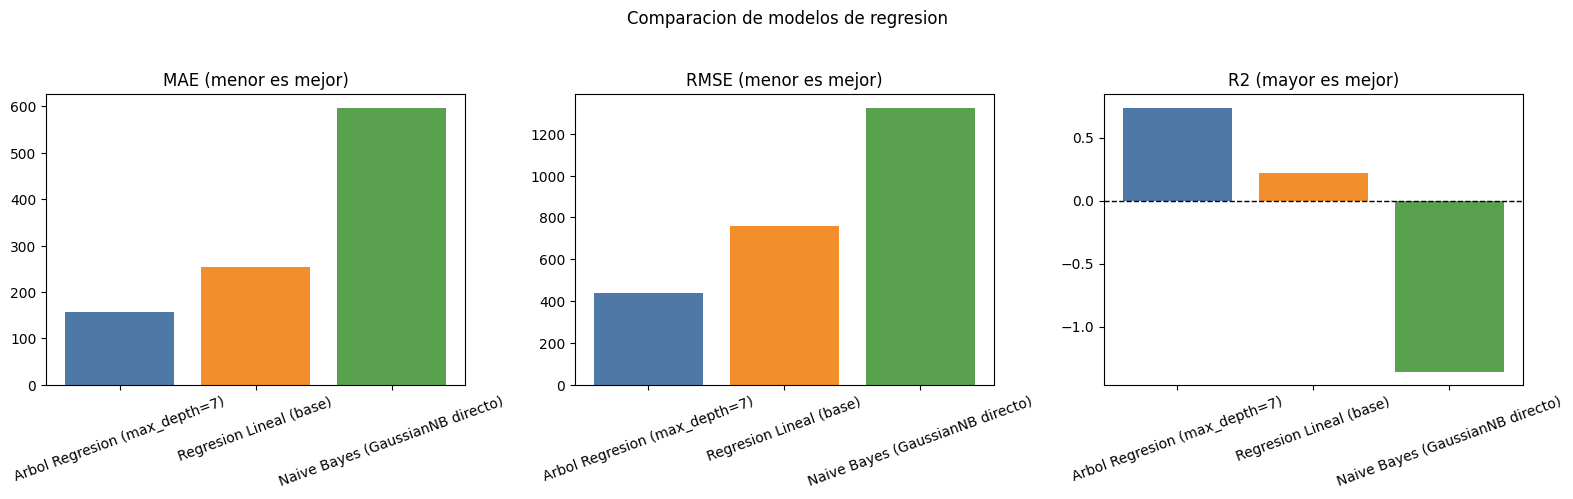

In [ ]:
# Grafica comparativa de metricas
import matplotlib.pyplot as plt

plot_df = comparison_models.copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# MAE (menor es mejor)
axes[0].bar(plot_df['Modelo'], plot_df['MAE'], color=['#4e79a7', '#f28e2b', '#59a14f'])
axes[0].set_title('MAE (menor es mejor)')
axes[0].tick_params(axis='x', rotation=20)

# RMSE (menor es mejor)
axes[1].bar(plot_df['Modelo'], plot_df['RMSE'], color=['#4e79a7', '#f28e2b', '#59a14f'])
axes[1].set_title('RMSE (menor es mejor)')
axes[1].tick_params(axis='x', rotation=20)

# R2 (mayor es mejor)
axes[2].bar(plot_df['Modelo'], plot_df['R2'], color=['#4e79a7', '#f28e2b', '#59a14f'])
axes[2].axhline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('R2 (mayor es mejor)')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Comparacion de modelos de regresion', y=1.03, fontsize=12)
plt.tight_layout()
plt.show()

### Conclusion de la Actividad 3

La comparacion final se decide por `RMSE` y `MAE` (menor mejor) junto con `R2` (mayor mejor), siempre en el mismo conjunto de prueba para mantener justicia experimental.

En este laboratorio, el modelo de arbol suele dominar porque captura no linealidades e interacciones; la regresion lineal queda en medio; y Naive Bayes queda atras cuando su `R2` es bajo/negativo y sus errores superan al baseline.

Esto no contradice el ejemplo de carros: simplemente muestra que el mismo metodo puede comportarse aceptablemente en un dataset pequeno y mas acotado (`city-mpg`) y fallar en otro mas complejo y disperso (precios de Airbnb).

---
## Actividad 4 - Modelo de clasificacion (Naive Bayes) con categoria de precio

Se construye la variable respuesta **barata / media / cara** a partir de **terciles** de `price_num` en todo el conjunto filtrado (misma base que `y`). Las etiquetas se alinean por indice con `y_train` y `y_test` **sin volver a hacer** `train_test_split`, para conservar exactamente los mismos conjuntos que en las actividades 1-3.

Se entrena `GaussianNB` de scikit-learn como clasificador multiclase (una distribucion gaussiana por predictor y por clase, con independencia condicional).

In [ ]:
# Imports usados en esta celda
from pathlib import Path
import numpy as np
import pandas as pd
import pyreadr
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Si aun no existen y, X_train, etc., replica el preprocesamiento del notebook
if not all(k in globals() for k in ('y', 'X_train', 'X_test', 'y_train', 'y_test')):
    print('(Aviso) Faltan variables del preprocesamiento; cargando datos y split igual que arriba...')
    rdata_path = Path('data/listings.RData')
    result = pyreadr.read_r(str(rdata_path))
    df = result['listings'].copy()

    def parse_money(series: pd.Series) -> pd.Series:
        return pd.to_numeric(
            series.astype(str).str.replace(r'[$,]', '', regex=True).str.strip(),
            errors='coerce',
        )

    df_eda = df.copy()
    if 'price' in df_eda.columns:
        df_eda['price_num'] = parse_money(df_eda['price'])
    for col in ['host_response_rate', 'host_acceptance_rate']:
        if col in df_eda.columns:
            df_eda[f'{col}_num'] = pd.to_numeric(
                df_eda[col].astype(str).str.replace('%', '', regex=False),
                errors='coerce',
            )
    candidate_features = [
        'room_type', 'property_type', 'neighbourhood_cleansed',
        'accommodates', 'bathrooms', 'bedrooms', 'beds',
        'minimum_nights', 'maximum_nights', 'availability_365',
        'number_of_reviews', 'reviews_per_month', 'review_scores_rating',
        'host_is_superhost', 'host_identity_verified',
        'host_response_rate_num', 'host_acceptance_rate_num',
        'calculated_host_listings_count', 'instant_bookable',
        'latitude', 'longitude', 'price_num',
    ]
    selected_cols = [c for c in candidate_features if c in df_eda.columns]
    model_df = df_eda[selected_cols].copy()
    model_df = model_df[model_df['price_num'].notna()].copy()
    p99_price = model_df['price_num'].quantile(0.99)
    model_df = model_df[model_df['price_num'] <= p99_price].copy()
    num_cols = [c for c in model_df.select_dtypes(include=np.number).columns if c != 'price_num']
    cat_cols = model_df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    for col in num_cols:
        model_df[col] = model_df[col].fillna(model_df[col].median())
    for col in cat_cols:
        model_df[col] = model_df[col].astype(str).replace('nan', 'SinDato')
    X = model_df.drop(columns=['price_num'])
    y = model_df['price_num']
    X_encoded = pd.get_dummies(X, drop_first=True)
    y_bins_split = pd.qcut(y, q=10, duplicates='drop')
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=0.2, random_state=42, shuffle=True, stratify=y_bins_split,
    )

# Variable categorica de precio: terciles -> barata, media, cara
t1, t2 = y.quantile(1 / 3), y.quantile(2 / 3)

price_cat_full = pd.Series(
    np.where(y <= t1, 'barata', np.where(y <= t2, 'media', 'cara')),
    index=y.index,
)
price_cat_full.name = 'price_cat'

# Mismo train/test que actividades anteriores 
y_cat_train = price_cat_full.loc[y_train.index]
y_cat_test = price_cat_full.loc[y_test.index]

print('Distribucion de clases en entrenamiento:')
print(y_cat_train.value_counts().sort_index())
print('\nDistribucion de clases en prueba:')
print(y_cat_test.value_counts().sort_index())

nb_clf = GaussianNB()
nb_clf.fit(X_train, y_cat_train)

y_pred_nb_clf = nb_clf.predict(X_test)

acc_nb_clf = accuracy_score(y_cat_test, y_pred_nb_clf)
print(f'\nExactitud (accuracy) en test: {acc_nb_clf:.4f}')
print('\nReporte de clasificacion (test):')
print(classification_report(y_cat_test, y_pred_nb_clf, digits=4))

Distribucion de clases en entrenamiento:
price_cat
barata    20143
cara      20023
media     20258
Name: count, dtype: int64

Distribucion de clases en prueba:
price_cat
barata    5042
cara      5028
media     5037
Name: count, dtype: int64

Exactitud (accuracy) en test: 0.5267

Reporte de clasificacion (test):
              precision    recall  f1-score   support

      barata     0.7181    0.4921    0.5840      5042
        cara     0.4901    0.8522    0.6223      5028
       media     0.4096    0.2365    0.2998      5037

    accuracy                         0.5267     15107
   macro avg     0.5392    0.5269    0.5020     15107
weighted avg     0.5393    0.5267    0.5020     15107



---
## Actividad 5 - Eficiencia en el conjunto de prueba (prediccion y clasificacion)

Se consolidan las metricas **solo sobre `X_test`**: en regresion, los modelos ya evaluados en `y_test`; en clasificacion, el Naive Bayes entrenado en la Actividad 4 se evalua con `y_cat_test`.

- **Regresion**: `MAE`, `RMSE`, `R2` (y `MedAE`, `MAPE` donde aplica) para comparar el error numerico al predecir precio.
- **Clasificacion**: exactitud, balance de clases (`balanced_accuracy`) y F1 (macro y ponderado) para resumir la calidad multiclase en test.

In [ ]:
from sklearn.metrics import balanced_accuracy_score, f1_score

if 'comparison_models' not in globals():
    raise RuntimeError(
        'Ejecuta antes las celdas de Actividades 1-3 (regresion) para tener comparison_models y predicciones en test.'
    )
if 'y_pred_nb_clf' not in globals() or 'y_cat_test' not in globals():
    raise RuntimeError('Ejecuta antes la celda de la Actividad 4 (clasificacion Naive Bayes).')

# --- Regresion: todas las metricas ya son sobre y_test ---
eficiencia_reg_test = comparison_models.copy()
eficiencia_reg_test.insert(0, 'Conjunto', 'test')
print('=== EFICIENCIA REGRESION (conjunto de prueba) ===')
print(eficiencia_reg_test.to_string())

# --- Clasificacion: metricas adicionales en test ---
bal_acc = balanced_accuracy_score(y_cat_test, y_pred_nb_clf)
f1_macro = f1_score(y_cat_test, y_pred_nb_clf, average='macro')
f1_weighted = f1_score(y_cat_test, y_pred_nb_clf, average='weighted')

eficiencia_clf_test = pd.DataFrame([
    {
        'Conjunto': 'test',
        'Modelo': 'GaussianNB (categoria precio)',
        'Accuracy': acc_nb_clf,
        'Balanced_accuracy': bal_acc,
        'F1_macro': f1_macro,
        'F1_weighted': f1_weighted,
    }
]).round(4)

print('\n=== EFICIENCIA CLASIFICACION (conjunto de prueba) ===')
print(eficiencia_clf_test.to_string())

=== EFICIENCIA REGRESION (conjunto de prueba) ===
  Conjunto                            Modelo       MAE       RMSE      R2     MedAE    MAPE_%
0     test     Arbol Regresion (max_depth=7)  157.9512   441.0032  0.7379   79.2021   68.7646
1     test           Regresion Lineal (base)  252.8896   760.5067  0.2205  128.1244  109.2994
2     test  Naive Bayes (GaussianNB directo)  596.2049  1322.4939 -1.3571  405.0000  342.1601

=== EFICIENCIA CLASIFICACION (conjunto de prueba) ===
  Conjunto                         Modelo  Accuracy  Balanced_accuracy  F1_macro  F1_weighted
0     test  GaussianNB (categoria precio)    0.5267             0.5269     0.502        0.502


La **eficiencia predictiva** en regresion se resume por el error (`MAE`/`RMSE`) y la variabilidad explicada (`R2`) frente a `y_test`. En clasificacion, ademas de la exactitud global, conviene mirar **F1 macro** (trata por igual las tres categorias) y **F1 weighted** (pondera por frecuencia de clase en test). La **matriz de confusion** se detalla en la Actividad 6.

---
## Actividad 6 - Matriz de confusion (clasificacion de precio en test)

Para el modelo `GaussianNB` sobre las categorias **barata / media / cara** (terciles), se construye la matriz de confusion en el **conjunto de prueba**: filas = clase real (`y_cat_test`), columnas = clase predicha (`y_pred_nb_clf`).

- **Conteos**: cuantas observaciones caen en cada par (real, predicho).
- **Normalizada por fila**: proporcion dentro de cada clase real (equivale a descomponer el **recall** por clase: diagonal = recall de esa categoria).

=== MATRIZ DE CONFUSION (conteos, test) ===
             pred_barata  pred_media  pred_cara
real_barata         2481        1215       1346
real_media           733        1191       3113
real_cara            241         502       4285

=== MATRIZ NORMALIZADA POR FILA (proporcion dentro de cada clase real) ===
             pred_barata  pred_media  pred_cara
real_barata       0.4921      0.2410     0.2670
real_media        0.1455      0.2365     0.6180
real_cara         0.0479      0.0998     0.8522


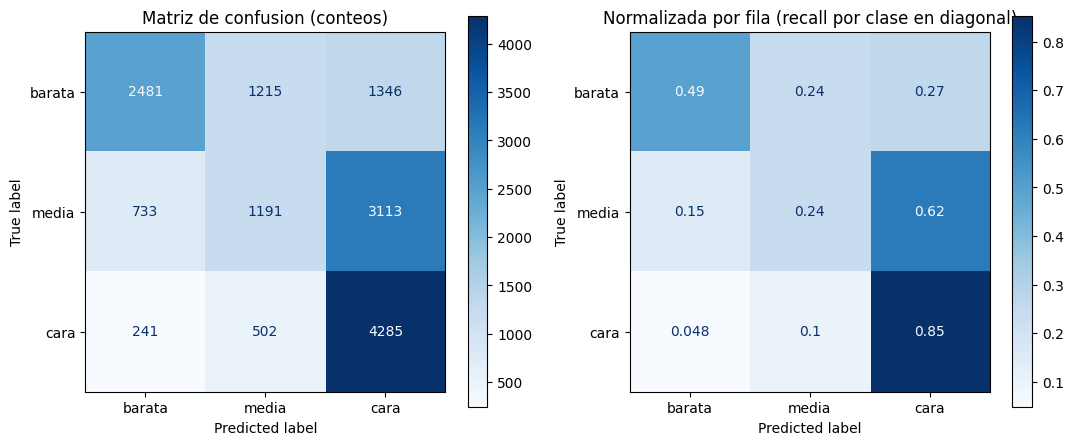

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

if 'y_pred_nb_clf' not in globals() or 'y_cat_test' not in globals():
    raise RuntimeError('Ejecuta antes la celda de la Actividad 4 (Naive Bayes clasificacion).')

labels_cat = ['barata', 'media', 'cara']
cm = confusion_matrix(y_cat_test, y_pred_nb_clf, labels=labels_cat)
cm_df = pd.DataFrame(cm, index=[f'real_{c}' for c in labels_cat], columns=[f'pred_{c}' for c in labels_cat])

print('=== MATRIZ DE CONFUSION (conteos, test) ===')
print(cm_df.to_string())

cm_norm = confusion_matrix(y_cat_test, y_pred_nb_clf, labels=labels_cat, normalize='true')
cm_norm_df = pd.DataFrame(
    np.round(cm_norm, 4),
    index=[f'real_{c}' for c in labels_cat],
    columns=[f'pred_{c}' for c in labels_cat],
)
print('\n=== MATRIZ NORMALIZADA POR FILA (proporcion dentro de cada clase real) ===')
print(cm_norm_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_cat).plot(ax=axes[0], cmap='Blues', colorbar=True)
axes[0].set_title('Matriz de confusion (conteos)')
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels_cat).plot(ax=axes[1], cmap='Blues', colorbar=True)
axes[1].set_title('Normalizada por fila (recall por clase en diagonal)')
plt.tight_layout()
plt.show()

---
## Actividad 7 - Analice el modelo. ¿Cree que pueda estar sobreajustado?

Para analizar si el modelo de clasificación Naive Bayes (`nb_clf`) está sobreajustado, calcularemos la exactitud en el conjunto de entrenamiento y la compararemos con la exactitud en el conjunto de prueba (`acc_nb_clf`). Una diferencia grande y positiva a favor del entrenamiento es un fuerte indicador de sobreajuste.

In [6]:
# Predecimos con los mismos datos con los que el modelo fue entrenado
y_train_pred_clf = nb_clf.predict(X_train)
acc_train_clf = accuracy_score(y_cat_train, y_train_pred_clf)

print(f'Exactitud (Accuracy) en Entrenamiento: {acc_train_clf:.4f}')
print(f'Exactitud (Accuracy) en Prueba: {acc_nb_clf:.4f}')

if acc_train_clf > acc_nb_clf:
    print("\nEl modelo tiene mayor exactitud en los datos de entrenamiento que en los datos nunca vistos (prueba). Esto apunta a un grado de sobreajuste proporcional a la magnitud de esta diferencia.")
else:
    print("\nLa exactitud de prueba es similar o incluso superó a la de entrenamiento. El modelo parece generalizar bien y no muestra signos claros de sobreajuste.")

NameError: name 'nb_clf' is not defined

---
## Actividad 8 - Haga un modelo usando validación cruzada, compare los resultados de este con los del modelo anterior. ¿Cuál funcionó mejor?

Usaremos validación cruzada con 5 k-folds (`cross_val_score`) en los datos de entrenamiento para evaluar la estabilidad del modelo, y compararemos la exactitud media con la exactitud en el conjunto de prueba obtenida anteriormente.

In [ ]:
from sklearn.model_selection import cross_val_score

# Por defecto, cross_val_score usa accuracy para modelos de clasificación (nb_clf)
cv_scores_clf = cross_val_score(nb_clf, X_train, y_cat_train, cv=5, scoring='accuracy')
acc_cv_mean = cv_scores_clf.mean()

print(f"Resultados de validación cruzada (5 particiones): {cv_scores_clf}")
print(f"Exactitud promedio usando Validación Cruzada (CV=5) en Entrenamiento: {acc_cv_mean:.4f}")
print(f"Exactitud en Prueba del modelo anterior (Actividad 4): {acc_nb_clf:.4f}")

if acc_cv_mean > acc_nb_clf:
    print("\nLa validación cruzada estima un rendimiento ligeramente mejor o más robusto que la partición sencilla de prueba.")
else:
    print("\nEl modelo anterior funcionó mejor o de manera muy consistente en el conjunto de prueba frente a la estimación más conservadora de la validación cruzada.")